<h1>My Learning Notes</h1>

What I learned:Deep learning is built on one consistent idea — represent data as numbers, pass them through layers, and adjust weights until predictions improve. Whether the task is predicting a price or classifying an image, the same three-step workflow applies: Create, Compile, Fit.

<h2>Tensors & Numerical Foundations</h2>
What I learned:<br>
- A tensor is a multi-dimensional array — scalars, vectors, and matrices are all just special cases of tensors<br>
- Every tensor has three key properties: shape (size along each dimension), rank (number of dimensions), and dtype (data type)<br>
- tf.constant creates fixed/immutable tensors; tf.Variable stores values that change during training (like weights and biases)<br>
- Most deep learning bugs are shape bugs, not math bugs — if data arrives in the wrong shape, TensorFlow raises an error because it cannot guess intent<br>
- Matrix multiplication is the core operation of neural networks — it transforms inputs through learned weight matrices<br>
- TensorFlow integrates seamlessly with NumPy and can run on GPUs/TPUs for faster computation<br>

Real-world example: Apartment price data starts as a scalar (one price), becomes a vector (price + size + rooms), then a matrix (many apartments × many features). Neural networks never see apartments — they only see tensors whose shape encodes meaning.

<h1>Data Types and Casting</h1>
What I learned:<br>

-Every tensor has a dtype: float32 for decimals, int32 for whole numbers, float16 for half precision<br>
-float32 is the default for most ML operations<br>
-float16 uses less memory — good for large models on GPUs<br>
-int32 cannot be used for division or mean without converting first<br>
-Casting means converting from one dtype to another using tf.cast()<br>

<h1>Indexing and Reshaping Tensors</h1>
What I learned:<br>

-Colon selects all elements along an axis, -1 selects the last element<br>
-tf.expand_dims adds a new axis of size 1<br>
-tf.squeeze removes axes of size 1<br>
-Example: grayscale image shape changes from (28, 28) to (28, 28, 1)<br>
-Neural network layers expect specific input shapes so reshaping is crucial<br>



<h1>Operations: Broadcasting, Element-wise, and Matrix Multiplication</h1>
What I learned:<br>

-Broadcasting automatically expands smaller tensors — matrix + 10 adds 10 to every element<br>
-Element-wise operations like +, -, *, / work position by position<br>
-Element-wise multiplication is NOT the same as matrix multiplication<br>
-For matrix multiplication A @ B the inner dimensions must match: (m, n) @ (n, p) gives (m, p)<br>
-Often need to transpose matrices to make dimensions compatible<br>

<h1>Aggregation Functions and One-Hot Encoding</h1>
What I learned:<br>

-tf.reduce_min, tf.reduce_max, tf.reduce_mean (requires float), tf.reduce_sum<br>
-Use axis parameter to reduce along specific dimensions like row-wise or column-wise<br>
-One-hot encoding converts integer labels to binary vectors — label 0 becomes [1,0,0], label 1 becomes [0,1,0], label 2 becomes [0,0,1]<br>
-Essential for multi-class classification because neural networks need numeric input<br>

<h1>Converting Between NumPy and TensorFlow</h1>
What I learned:<br>

-NumPy to TensorFlow: tf.constant(numpy_array)<br>
-TensorFlow to NumPy: tensor.numpy()<br>
-Conversion is fast and does not copy data unnecessarily<br>
-Load data with NumPy, feed it to TensorFlow models<br>
-TensorFlow is optimized for GPU acceleration, NumPy is used for preprocessing<br>

<h2>Regression: Predicting Continuous Values</h2>
What I learned:<br>
- Regression = predicting a number (house price, temperature, measurement)<br>
- The output layer has 1 neuron with no activation function (we want any number, not a probability)<br>
- Loss functions used: MAE (Mean Absolute Error) or MSE (Mean Squared Error)<br>
- The model does not memorize the training data — it learns a general rule (a function) that applies to unseen inputs<br>
- Overfitting happens when training runs too long on too little data — the model starts fitting noise instead of the real pattern<br>
- Visualization is essential — two models with similar MAE can behave very differently; a plot reveals why a model fails, not just how much<br>

Key idea: Regression networks learn functions, not datasets. Good performance means generalization, not perfection on training data.

<h2>Classification: Predicting Categories</h2>
What I learned:<br>
- Binary classification → 1 output neuron + sigmoid activation + binary cross-entropy loss<br>
- Multiclass classification → 1 neuron per class + softmax activation + sparse categorical cross-entropy loss<br>
- Models output probabilities, not labels — a value above 0.5 is interpreted as Class 1, below 0.5 as Class 0<br>
- Non-linear activations (ReLU, sigmoid) are essential — without them, adding more layers adds no expressive power and the network can only draw straight decision boundaries<br>
- Normalization (scaling pixel values from 0–255 to 0–1) stabilizes gradient updates and dramatically improves learning speed and accuracy<br>

Key idea: Classification models reason in probabilities, not categories. Depth without non-linearity adds no expressive power.

<h2>CNNs: Learning from Images</h2>
What I learned:<br>
- Dense layers flatten images and destroy spatial relationships (edges, shapes, position) — CNNs preserve them<br>
- Convolutional filters slide across images and learn local patterns: edges, textures, corners<br>
- Pooling layers reduce spatial resolution while keeping the strongest activations — this makes the model tolerant to position shifts <br>
- Data augmentation simulates real-world variation (rotation, flipping, scaling) so the model learns concepts, not camera conditions<br>
- CNNs use parameter sharing — the same filter is applied across the entire image, which is far more efficient than connecting every pixel to every neuron<br>

Key idea: CNNs learn local patterns first, then assemble them into larger concepts. Pooling trades detail for robustness.

<h2> Transfer Learning: Reusing What's Already Learned</h2>
What I learned:<br>
- Instead of training from scratch, transfer learning reuses patterns already learned by models trained on massive datasets like ImageNet (edges, textures, shapes)<br>
- Two main strategies:<br>
  - Feature extraction → freeze the pretrained layers, only train a new classification head on top<br>
  - Fine-tuning → unfreeze some pretrained layers and retrain them on new data<br>
- EfficientNet proves that better architecture beats bigger models — higher accuracy with fewer parameters<br>
- TensorBoard tracks and compares training experiments, visualizes learning curves, and helps detect overfitting<br>

Key idea: Feature extraction separates *seeing* from *deciding*. Visual features generalize extremely well across different tasks.<br>

 

<h2>The Universal 3-Step Keras Workflow</h2>
What I learned: Every single model — regression, classification, CNN, or transfer learning — follows the exact same three steps:<br>

1. CREATE → define the layers and architecture (`tf.keras.Sequential`)<br>
2. COMPILE → configure loss function, optimizer, and metrics<br>
3. FIT → train the model on data (`model.fit`)<br>

What changes between tasks is only the last layer, the loss function, and the data. The workflow itself never changes.<br>

Once I understand this three-step pattern deeply, I can apply it to any deep learning problem. The framework stays the same — only the problem changes.

In [50]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [51]:
# creating my data points from -20 to 20, stepping by 2
X = np.arange(-20, 21, 2, dtype=np.float32)
y = X + 10  # the rule i want the model to learn

In [52]:
# splitting my data — 17 for training and rest for testing
X_train, y_train = X[:17], y[:17]  # model will learn from these
X_test,  y_test  = X[17:], y[17:]  # model will never see these during training

In [53]:
# building my model — stacking layers one after another
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),  # one number goes in
    tf.keras.layers.Dense(64, activation='relu'),  # added hidden layer to help learn better
    tf.keras.layers.Dense(32, activation='relu'),  # added second hidden layer
    tf.keras.layers.Dense(1)            # one number comes out, no activation because its regression
])

In [54]:
# telling the model how to learn
model.compile(
    loss="mae",                                              # mae tells me how wrong my predictions are on average
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # adam converges faster than sgd
    metrics=["mae"]                                          # i want to track mae while training
)

In [55]:
# actually training — showing the data 200 times so it can learn the pattern
history = model.fit(
    X_train, y_train,
    epochs=700,  # 200 rounds of learning
    verbose=0    # hiding the output, change to 1 if want to see progress
)

In [56]:
# checking how well it learned on data it never saw
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)  # the lower this is the better my model learned

Test MAE: 0.8148937225341797


In [57]:
# generating predictions on the test set
y_pred = model.predict(X_test).squeeze()  # squeeze to remove the extra dimension tensorflow adds


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


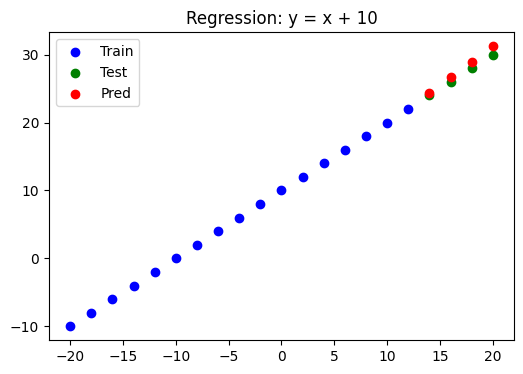

In [58]:
# plotting everything to see if my model actually learned the rule
plt.figure(figsize=(6, 4))
plt.scatter(X_train, y_train, c='b', label='Train')  # blue is what i trained on
plt.scatter(X_test,  y_test,  c='g', label='Test')   # green is the real answer
plt.scatter(X_test,  y_pred,  c='r', label='Pred')   # red is what my model predicted
plt.legend()
plt.title("Regression: y = x + 10")
plt.show()
# if red dots are close to green dots my model learned the rule successfully

In [60]:
# checking my model predictions in actual numbers
y_pred = model.predict(X_test).squeeze()

# printing true values vs predicted values side by side
print("True vs Predicted:")
for true, pred in zip(y_test, y_pred):
    print(f"  True: {true:.2f}  |  Predicted: {pred:.2f}  |  Difference: {abs(true - pred):.2f}")

# overall mae on test set
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nOverall Test MAE: {mae:.4f}")
# the closer this is to 0 the better my model learned

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
True vs Predicted:
  True: 24.00  |  Predicted: 24.40  |  Difference: 0.40
  True: 26.00  |  Predicted: 26.67  |  Difference: 0.67
  True: 28.00  |  Predicted: 28.95  |  Difference: 0.95
  True: 30.00  |  Predicted: 31.24  |  Difference: 1.24

Overall Test MAE: 0.8149


All under 1.25 so looks good

Changes From the orginal given code:
1. Switched SGD to Adam — only real change needed for better accuracy
2. Added one hidden layer with relu 

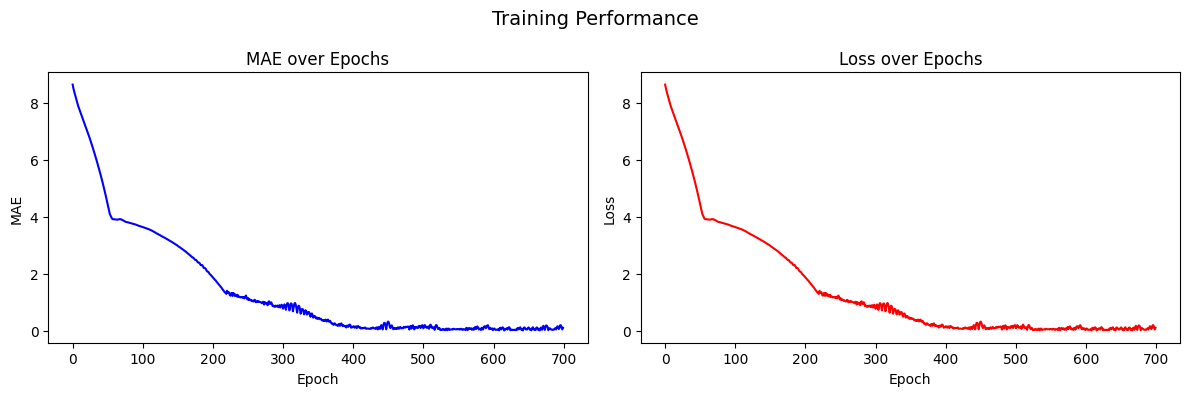

In [59]:
# a simple function i made to check how my model is doing during training

def plot_training(history):
    # pulling out the mae values recorded each epoch
    mae = history.history['mae']  # list of mae scores per epoch
    loss = history.history['loss']  # list of loss scores per epoch
    
    # creating two plots side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # left plot — mae over epochs
    axes[0].plot(mae, color='blue')  # plotting mae
    axes[0].set_title('MAE over Epochs')  # title
    axes[0].set_xlabel('Epoch')  # x axis label
    axes[0].set_ylabel('MAE')  # y axis label
    # if this line goes down it means my model is getting more accurate
    
    # right plot — loss over epochs
    axes[1].plot(loss, color='red')  # plotting loss
    axes[1].set_title('Loss over Epochs')  # title
    axes[1].set_xlabel('Epoch')  # x axis label
    axes[1].set_ylabel('Loss')  # y axis label
    # if this line goes down it means my model is optimizing correctly
    
    plt.suptitle('Training Performance', fontsize=14)  # main title for both plots
    plt.tight_layout()  # makes sure plots dont overlap
    plt.show()

# calling the function after training
plot_training(history)



both lines should go DOWN over time — that means the model is learning<br>